# ATENA-TF Master Welcome — Google Colab Edition

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Eden-Mironi/Atena-TF/blob/main/Notebooks/ATENA-TF-Master-Welcome-Colab.ipynb)

**One-click start:** Click **Runtime → Run all** and wait ~2 min for setup, then explore!

This notebook is the exact port of ATENA-Master's Welcome notebook to TensorFlow 2.
It demonstrates the environment, reward system, and custom action sequences — no training required.

---


In [1]:
# ── Colab / Local Setup ──────────────────────────────────────────────────────
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess

    print("📦 Installing additional packages (Colab already has TF, numpy, gym, scipy…)")
    # Do NOT install numpy or gym — Colab's versions are pre-compiled and compatible.
    # Installing numpy<2.0 downgrades numpy and causes a binary mismatch with
    # Colab's system C extensions, crashing the kernel.
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
        "tensorflow-probability>=0.24.0",
        "snorkel==0.10.0",
        "cachetools", "zss", "nltk", "openpyxl"])
    print("✅ Packages installed!")

    if not os.path.exists("/content/atena-tf"):
        print("📥 Cloning ATENA-TF from GitHub…")
        subprocess.check_call(["git", "clone",
            "https://github.com/Eden-Mironi/Atena-TF.git",
            "/content/atena-tf"])
        print("✅ Repository cloned!")

    os.chdir("/content/atena-tf")

    if "/content/atena-tf" not in sys.path:
        sys.path.insert(0, "/content/atena-tf")

    print("✅ ATENA-TF project ready!")

print(f"🌍 Environment : {'Google Colab' if IN_COLAB else 'Local Jupyter'}")
print(f"📁 Working dir : {os.getcwd()}")


📦 Installing additional packages (Colab already has TF, numpy, gym, scipy…)
✅ Packages installed!
📥 Cloning ATENA-TF from GitHub…
✅ Repository cloned!
✅ ATENA-TF project ready!
🌍 Environment : Google Colab
📁 Working dir : /content/atena-tf


# ATENA-TF Master Welcome

## Exact Port of ATENA-Master Welcome Notebook to TensorFlow 2

This notebook replicates the exact structure of the original `ATENA- Welcome.ipynb` from ATENA-master,
but uses the TensorFlow 2 framework components.

### 📂 Important: Working Directory

**To run this notebook successfully**, start Jupyter from the project root directory:

```bash
# From the atena-tf 2 directory (NOT from Notebooks/)
cd /path/to/atena-tf-2
jupyter notebook
# Then open: Notebooks/ATENA-TF-Master-Welcome.ipynb
```

Alternatively, if running from within Notebooks/, the path setup in the next cell will automatically adjust.

### What you'll learn:
- Environment properties and setup
- Running random "agent" exploration
- Executing custom action sequences
- Understanding the action space and observations
- Viewing reward components and analysis
- Analyst view for detailed exploration


In [2]:
# Fix for gym 0.25.2 compatibility with newer numpy
import numpy as np
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

# Setup paths - ensure we can import from parent directory
import sys
import os

# Get the notebook's directory and add parent to path
notebook_dir = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
parent_dir = os.path.dirname(notebook_dir) if "Notebooks" in notebook_dir else notebook_dir

# Add to path if not already there
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# Core imports
import scipy as sp
import gym

# ATENA imports
import Configuration.config as cfg
from gym_atena.envs.atena_env_cont import ATENAEnvCont
from Evaluation.notebook_utils import *

%matplotlib inline

print("✅ All imports successful!")
print(f"📊 Working directory: {os.getcwd()}")
print(f"🎯 Schema: {cfg.schema}")
print(f"📈 Max steps per episode: {cfg.MAX_NUM_OF_STEPS}")


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Configuration loaded with:
  - humanity_coeff: 1.0
  - diversity_coeff: 2.0
  - kl_coeff: 1.5
  - compaction_coeff: 2.0
  - adam_lr: 0.0003
  - ppo_gamma: 0.995
  - ppo_lambda: 0.97
Registering ATENAcont-v0 environment


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/content/atena-tf/gym_atena/lib/tokenization.py:34: SyntaxWarning: invalid escape sequence '\['
  for token in re.findall('\[.*?\]', line):
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent

Using Snorkel compatibility adapter


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Configuration loaded with:
  - humanity_coeff: 1.0
  - diversity_coeff: 2.0
  - kl_coeff: 1.5
  - compaction_coeff: 2.0
  - adam_lr: 0.0003
  - ppo_gamma: 0.995
  - ppo_lambda: 0.97
REWARD STABILIZER: DISABLED (stable mode like train_ipdate-1009-18:54.png)
✅ All imports successful!
📊 Working directory: /content/atena-tf
🎯 Schema: NETWORKING
📈 Max steps per episode: 12


## Environment Setup

Create the ATENA environment. The environment will automatically load the Snorkel model for humanity scoring.


In [3]:
%%capture
env = gym.make(env_d)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Environment Properties

Let's explore the action and observation spaces:


In [4]:
# Print environment properties
print("action space size is: ", env.action_space)
print("action space low is: ", env.action_space.low)
print("action space high is: ", env.action_space.high)
print("observation space dimensions are: ", env.observation_space)
print("observation space dimensions are: ", env.observation_space.low)
print("observation space dimensions are: ", env.observation_space.high)
print("reward range is:", env.reward_range)


action space size is:  Box(-3.0, 3.0, (6,), float32)
action space low is:  [-3. -3. -3. -3. -3. -3.]
action space high is:  [3. 3. 3. 3. 3. 3.]
observation space dimensions are:  Box([ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.  0.  0.  0.], [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 1. 1. 1.], (51,), float32)
observation space dimensions are:  [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.  0.  0.  0.]
observation space dimensions are:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 1. 1. 1.]

## Reset Environment

Reset to the first dataset and view the initial observation:


In [5]:
print(env.reset())
print("dataset number %d" % env.dataset_number)


[ 1.          0.          1.          0.00939597  0.          0.23802279
  0.00671141  0.          0.20815389  0.01610738  0.          0.23036283
  0.53959733  0.          0.7583536   0.02818792  0.          0.38602573
  0.02550336  0.          0.34799948  0.13959731  0.          0.50405794
  0.15973154  0.          0.59122396  0.03624161  0.          0.34320706
  0.03624161  0.          0.31525862  0.03489933  0.          0.4186772
 -1.         -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.
  0.          0.          0.        ]
dataset number 2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Run a Random "Agent"

Let's run a random agent that takes random actions in the environment:


In [6]:
info_hist, r_sum = run_episode(env=env, compressed=True)
simulate(info_hist)


[-2.7413688  -2.7325613   2.337187    2.9661915  -0.48629323 -1.3522451 ]
BACK ACTION: humanity rewards only
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.500, std=0.000
BEFORE coeff: r_snorkel_humanity=0.000000
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=0.000000
Snorkel humanity: 0.000000


/usr/local/lib/python3.12/dist-packages/gym/core.py:49: DeprecationWarning: WARN: You are calling render method, but you didn't specified the argument render_mode at environment initialization. To maintain backward compatibility, the environment will render in human mode.
If you want to render in human mode, initialize the environment in this way: gym.make('EnvName', render_mode='human') and don't call the render method.
See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


'Back'

[-0.8757493  -0.42553797  1.7165072   2.64411    -1.1071757  -1.3732837 ]
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.020, std=0.000
Diversity coefficient applied (main calc): 2.0
KL coefficient applied: 1.5
MASTER-EXACT REWARD:
   action_type: 1
   kl_distance: 0.390622479048344
   compaction_gain: 0
   total_interestingness: 0.390622479048344
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.020, std=0.000
BEFORE coeff: r_snorkel_humanity=-0.959687
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=-0.959687
Snorkel humanity: -0.959687


"Filter on Column 'ip_dst', using condition 'str.contains', with term '10.42.42.253'"

...

"Group on Column 'info_line' and aggregate with '<built-in function len>' on the column 'packet_number'"

[ 0.5384534   0.05872484  1.9073799  -0.5318341   0.74409336  0.8263272 ]
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.500, std=0.000
Diversity coefficient applied (main calc): 2.0
KL coefficient applied: 1.5
MASTER-EXACT REWARD:
   action_type: 1
   kl_distance: 0.9316122115659284
   compaction_gain: 0
   total_interestingness: 0.9316122115659284
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.500, std=0.000
BEFORE coeff: r_snorkel_humanity=0.000000
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=0.000000
Snorkel humanity: 0.000000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


"Filter on Column 'ip_src', using condition 'str.contains', with term '10.42.42.253'"

[np.int64(0), np.int64(0), np.int64(8), np.float64(0.49436521530151367), np.int64(0), np.int64(0)],
[np.int64(1), np.int64(5), np.int64(7), np.float64(0.440684974193573), np.int64(0), np.int64(0)],
[np.int64(0), np.int64(8), np.int64(6), np.float64(0.3050021529197693), np.int64(0), np.int64(0)],
[np.int64(0), np.int64(11), np.int64(4), np.float64(-0.43401142209768295), np.int64(0), np.int64(0)],
[np.int64(1), np.int64(11), np.int64(2), np.float64(-0.3697185516357422), np.int64(0), np.int64(0)],
[np.int64(2), np.int64(2), np.int64(6), np.float64(0.0938103199005127), np.int64(0), np.int64(0)],
[np.int64(2), np.int64(4), np.int64(7), np.float64(-0.10734567046165466), np.int64(0), np.int64(0)],
[np.int64(1), np.int64(5), np.int64(3), np.float64(-0.14435788989067078), np.int64(0), np.int64(0)],
[np.int64(2), np.int64(11), np.int64(4), np.float64(0.47292256355285645), np.int64(0), np.int64(0)],
[np.int64(0), np.int64(9), np.int64(0), np.float64(0.09546607732772827), np.int64(0), np.int64(0)]

# Run Custom Actions

Now let's run a specific sequence of actions on dataset 0 (Flights dataset).

This example explores large flight delays from DFW airport:
1. Group by departure_delay
2. Filter to LARGE_DELAY
3. Group by origin_airport
4. Filter to DFW
5. Group by delay_reason
6. Group by scheduled_departure
7-12. Navigate back through the states


In [7]:
# Set dataset_number
dataset_number = 0

# Set actions
action_vecs = [
[2, 6, 1, 0.3221167325973511, 0, 0],      #  1: Group by departure_delay
[1, 6, 1, -0.48, 0, 0],                   #  2: Filter LARGE_DELAY
[2, 2, 7, 0.48046758365631, 0, 0],        #  3: Group by origin_airport
[1, 2, 1, 0.48086163997650146, 0, 0],     #  4: Filter DFW
[2, 5, 8, -0.48018680667877, 0, 0],       #  5: Group by delay_reason
[2, 8, 8, 0.444186806678772, 0, 0],       #  6: Group by scheduled_departure
[0, 7, 4, 0.6415030360221863, 0, 0],      #  7: Back
[0, 5, 4, 0.8115951418876648, 0, 0],      #  8: Back
[2, 11, 1, -0.48, 0, 0],                  #  9: Group by day_of_year
[0, 5, 1, -0.45, 0, 0],                   # 10: Back
[0, 11, 4, 0.6415030360221863, 0, 0],     # 11: Back
[0, 6, 1, 0.5015030360221863, 0, 0],      # 12: Back
]

info_hist, r_sum = run_episode(
    dataset_number=dataset_number,
    env=env,
    compressed=False,
    filter_by_field=True,
    continuous_filter_term=True,
    actions_lst=action_vecs,
)

simulate(info_hist, displays=True)


[2, 6, 1, 0.3221167325973511, 0, 0]
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.013, std=0.000
Diversity coefficient applied (main calc): 2.0
Compaction coefficient applied: 2.0
MASTER-EXACT REWARD:
   action_type: 2
   kl_distance: 0
   compaction_gain: 0.2923061463621609
   total_interestingness: 0.2923061463621609
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.013, std=0.000
BEFORE coeff: r_snorkel_humanity=-0.973673
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=-0.973673
Snorkel humanity: -0.973673


/usr/local/lib/python3.12/dist-packages/gym/core.py:49: DeprecationWarning: WARN: You are calling render method, but you didn't specified the argument render_mode at environment initialization. To maintain backward compatibility, the environment will render in human mode.
If you want to render in human mode, initialize the environment in this way: gym.make('EnvName', render_mode='human') and don't call the render method.
See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


"Group on Column 'ip_src' and aggregate with '<built-in function len>' on the column 'packet_number'"

[1, 6, 1, -0.48, 0, 0]
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.014, std=0.000
Diversity coefficient applied (main calc): 2.0
KL coefficient applied: 1.5
MASTER-EXACT REWARD:
   action_type: 1
   kl_distance: 1.1118442475364003
   compaction_gain: 0
   total_interestingness: 1.1118442475364003
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.014, std=0.000
BEFORE coeff: r_snorkel_humanity=-0.971397
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=-0.971397
Snorkel humanity: -0.971397


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

action: Back , reward: -1.2560980443541785
raw action: [np.int64(0), np.int64(6), np.int64(1), np.float32(0.501503), np.int64(0), np.int64(0)]
dict_items([('empty_display', 0), ('empty_groupings', 0), ('same_display_seen_already', 0), ('back', 0), ('diversity', 0), ('interestingness', 0), ('kl_distance', 0), ('compaction_gain', 0), ('humanity', np.float64(-0.5280490221770893)), ('snorkel_humanity', np.float64(-0.9280490221770893)), ('rules_based_humanity', 0.2), ('human_sessions_similarity', 0), ('coherency_score', 0), ('readability_score', 0), ('diversity_components', {'display_distance': 0.0, 'same_display_penalty': False, 'is_back_action': True}), ('interestingness_components', {'kl_divergence': 0, 'compaction_gain': 0, 'information_gain': 0})])



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,packet_number
ip_src,
82.108.11.111,8


Total Reward: -11.600058695690818


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Understanding the Output

For each action, you'll see:
- **Raw action vector**: `[action_type, param1, param2, param3, param4, param5]`
- **Action description**: Human-readable action
- **Reward**: Total reward for this step
- **Reward components**: Breakdown of reward
  - `empty_display`: Penalty for empty results
  - `empty_groupings`: Penalty for empty groups
  - `same_display_seen_already`: Penalty for redundant actions
  - `back`: Reward for back actions
  - `diversity`: Reward for diverse exploration
  - `interestingness`: Reward for interesting patterns
  - `kl_distance`: KL divergence measure
  - `compaction_gain`: Data compaction reward
  - `humanity`: Rule-based humanity score
  - `snorkel_humanity`: ML-based humanity score
- **Human rules triggered**: Which human behavior rules matched
- **Snorkel rules triggered**: Which ML rules matched
- **Resulting DataFrame**: The data after applying the action


# Run Another Custom Action Sequence

Let's explore a different dataset (dataset 1):


In [8]:
# Set dataset_number
dataset_number = 1

# Set actions
action_vecs = [
[2, 3, 0, 0.0, 0, 0],                     #  1: Group action
[1, 4, 8, -0.462690144777298, 0, 0],      #  2: Filter action
[0, 0, 0, 0.0, 0, 0],                     #  3: Back
[0, 0, 0, 0.0, 0, 0],                     #  4: Back
[1, 5, 2, -0.48248493671417236, 0, 0],    #  5: Filter action
[0, 0, 0, 0.0, 0, 0],                     #  6: Back
[2, 2, 0, 0.0, 0, 0],                     #  7: Group action
[2, 6, 0, 0.0, 0, 0],                     #  8: Group action
[2, 5, 0, 0.0, 0, 0],                     #  9: Group action
[1, 4, 8, -0.4228319823741913, 0, 0],     # 10: Filter action
[0, 0, 0, 0.0, 0, 0],                     # 11: Back
[1, 4, 8, -0.41552573442459106, 0, 0],    # 12: Filter action
]

info_hist, r_sum = run_episode(
    dataset_number=dataset_number,
    env=env,
    compressed=False,
    filter_by_field=True,
    continuous_filter_term=True,
    actions_lst=action_vecs,
)

simulate(info_hist, displays=True)


[2, 3, 0, 0.0, 0, 0]
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.010, std=0.000
Diversity coefficient applied (main calc): 2.0
Compaction coefficient applied: 2.0
MASTER-EXACT REWARD:
   action_type: 2
   kl_distance: 0
   compaction_gain: 1.8782773540271902
   total_interestingness: 1.8782773540271902
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.010, std=0.000
BEFORE coeff: r_snorkel_humanity=-0.979474
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=-0.979474
Snorkel humanity: -0.979474


/usr/local/lib/python3.12/dist-packages/gym/core.py:49: DeprecationWarning: WARN: You are calling render method, but you didn't specified the argument render_mode at environment initialization. To maintain backward compatibility, the environment will render in human mode.
If you want to render in human mode, initialize the environment in this way: gym.make('EnvName', render_mode='human') and don't call the render method.
See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


"Group on Column 'highest_layer' and aggregate with '<built-in function len>' on the column 'packet_number'"

[1, 4, 8, -0.462690144777298, 0, 0]
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.020, std=0.000
Diversity coefficient applied (main calc): 2.0
KL coefficient applied: 1.5
MASTER-EXACT REWARD:
   action_type: 1
   kl_distance: 1.1132960568215122
   compaction_gain: 0
   total_interestingness: 1.1132960568215122
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.020, std=0.000
BEFORE coeff: r_snorkel_humanity=-0.960628
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=-0.960628
Snorkel humanity: -0.960628


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

,,,packet_number
eth_src,ip_src,ip_dst,
00:08:e2:3b:56:01,98.114.205.102,192.150.11.111,195
00:30:48:62:4e:4a,192.150.11.111,98.114.205.102,153


action: Filter on Column 'info_line', using condition 'str.contains', with term '[PSH, ACK]' , reward: -2.0
raw action: [np.int64(1), np.int64(4), np.int64(8), np.float32(-0.41552573), np.int64(0), np.int64(0)]
dict_items([('empty_display', 0), ('empty_groupings', 0), ('same_display_seen_already', -1.0), ('back', 0), ('diversity', -1.0), ('interestingness', 0), ('kl_distance', 0), ('compaction_gain', 0), ('humanity', np.float64(0.0)), ('snorkel_humanity', np.float64(0.0)), ('rules_based_humanity', 0), ('human_sessions_similarity', 0), ('coherency_score', 0), ('readability_score', 0), ('diversity_components', {'display_distance': 0.0, 'same_display_penalty': True, 'penalty_scale_factor': 1.0}), ('interestingness_components', {'kl_divergence': 0, 'compaction_gain': 0, 'information_gain': 0})])



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,,,packet_number
eth_src,ip_src,ip_dst,
00:08:e2:3b:56:01,98.114.205.102,192.150.11.111,11
00:30:48:62:4e:4a,192.150.11.111,98.114.205.102,9


Total Reward: 6.541112277157389


# Analyst View

The Analyst View provides a richer, more detailed display of the exploration session:
- HTML-formatted action descriptions
- Navigation buttons to jump between states
- Visual tree of the exploration path
- Current filtering state display
- Interactive dataframe displays


/usr/local/lib/python3.12/dist-packages/gym/core.py:49: DeprecationWarning: WARN: You are calling render method, but you didn't specified the argument render_mode at environment initialization. To maintain backward compatibility, the environment will render in human mode.
If you want to render in human mode, initialize the environment in this way: gym.make('EnvName', render_mode='human') and don't call the render method.
See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,packet_number,eth_dst,eth_src,highest_layer,info_line,ip_dst,ip_src,length,sniff_timestamp,tcp_dstport,tcp_srcport,tcp_stream
0,0,70:5a:b6:51:d7:b2,00:23:8b:82:1f:4a,TCP,46104?80 [SYN] Seq=0 Win=5840 Len=0 MSS=1460 S...,10.42.42.50,10.42.42.253,74,2010-02-03 01:34:06,80,46104,0
1,1,00:23:8b:82:1f:4a,70:5a:b6:51:d7:b2,TCP,"80 > 46104 [RST, ACK] Seq=1 Ack=1 Win=0 Len=0",10.42.42.253,10.42.42.50,60,2010-02-03 01:34:06,46104,80,0
2,2,00:26:22:cb:1e:79,00:23:8b:82:1f:4a,TCP,59856 > 80 [SYN] Seq=0 Win=5840 Len=0 MSS=1460...,10.42.42.56,10.42.42.253,74,2010-02-03 01:34:07,80,59856,1
3,3,00:16:cb:92:6e:dc,00:23:8b:82:1f:4a,TCP,40921 > 80 [SYN] Seq=0 Win=5840 Len=0 MSS=1460...,10.42.42.25,10.42.42.253,74,2010-02-03 01:34:07,80,40921,2
4,4,00:23:8b:82:1f:4a,00:26:22:cb:1e:79,TCP,"80 > 59856 [RST, ACK] Seq=1 Ack=1 Win=0 Len=0",10.42.42.253,10.42.42.56,60,2010-02-03 01:34:07,59856,80,1
...,...,...,...,...,...,...,...,...,...,...,...,...
13620,13620,00:23:8b:82:1f:4a,00:26:22:cb:1e:79,TCP,"1 > 36136 [RST, ACK] Seq=1 Ack=1 Win=0 Len=0",10.42.42.253,10.42.42.56,60,2010-02-03 01:44:12,36136,1,7435
13621,13621,00:26:22:cb:1e:79,00:23:8b:82:1f:4a,TCP,[TCP ACKed unseen segment] 36137 > 1 [ACK] Seq...,10.42.42.56,10.42.42.253,74,2010-02-03 01:44:13,1,36137,7425
13622,13622,00:23:8b:82:1f:4a,00:26:22:cb:1e:79,TCP,1 > 36137 [RST] Seq=1221632195 Win=0 Len=0,10.42.42.253,10.42.42.56,60,2010-02-03 01:44:13,36137,1,7425
13623,13623,00:26:22:cb:1e:79,00:23:8b:82:1f:4a,TCP,"[TCP Retransmission] 36138 > 1 [FIN, PSH, URG]...",10.42.42.56,10.42.42.253,74,2010-02-03 01:44:13,1,36138,7428


Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.013, std=0.000
Diversity coefficient applied (main calc): 2.0
Compaction coefficient applied: 2.0
MASTER-EXACT REWARD:
   action_type: 2
   kl_distance: 0
   compaction_gain: 1.9804895199986374
   total_interestingness: 1.9804895199986374
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.013, std=0.000
BEFORE coeff: r_snorkel_humanity=-0.973673
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=-0.973673
Snorkel humanity: -0.973673


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/gym/spaces/box.py:128: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/content/atena-tf/gym_atena/envs/atena_snorkel/snorkel_compatibility.py:122: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  return super().find_class(module, name)


Fixing old snorkel.learning references in checkpoint...
Successfully loaded Snorkel checkpoint with compatibility fixes
Initializing real LabelModel with checkpoint data...
   Fitting LabelModel with dummy data: L_train(100, 51), class_balance=[0.5, 0.5]
Real LabelModel initialized and ready for predictions!
Loaded Snorkel model from snorkel_checkpoints


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


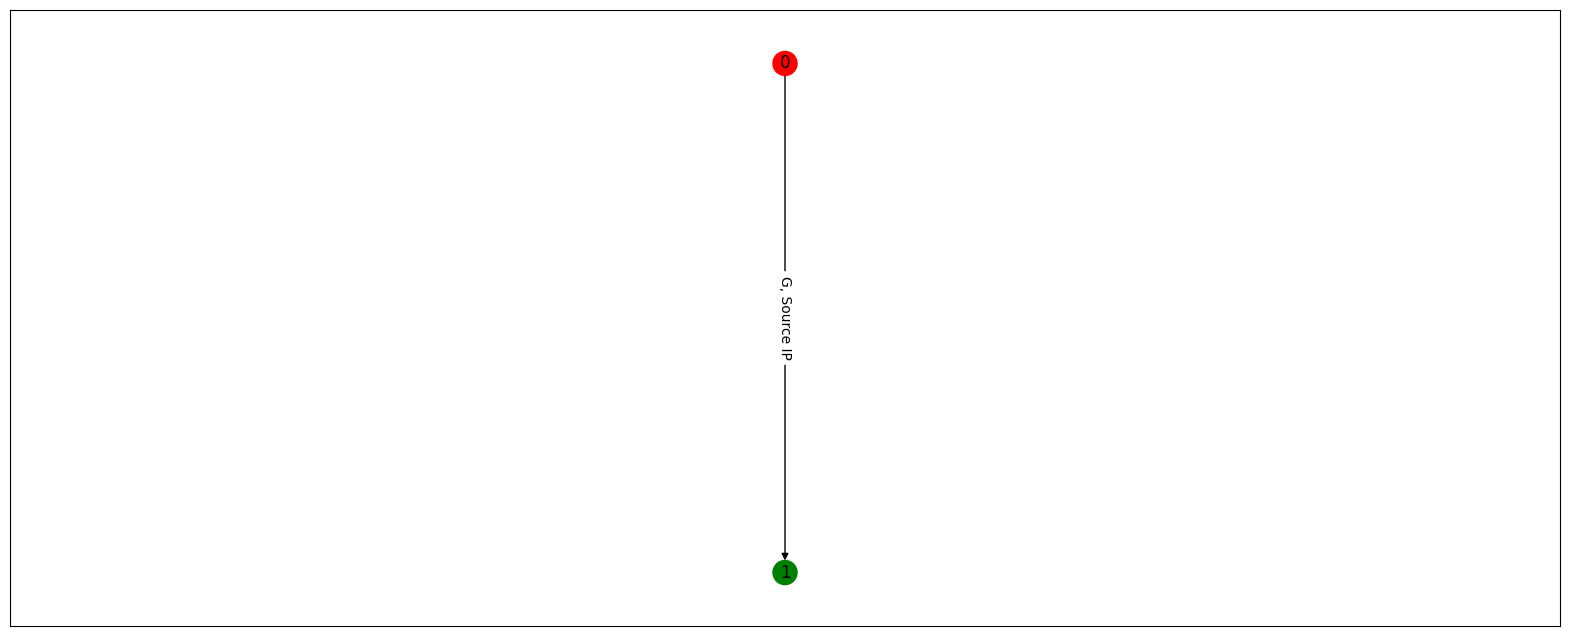

,packet_number
ip_src,
10.42.42.25,2071
10.42.42.253,7462
10.42.42.50,2079
10.42.42.56,2013


Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.005, std=0.000
Diversity coefficient applied (main calc): 2.0
Compaction coefficient applied: 2.0
MASTER-EXACT REWARD:
   action_type: 2
   kl_distance: 0
   compaction_gain: 1.771858860276165
   total_interestingness: 1.771858860276165
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.005, std=0.000
BEFORE coeff: r_snorkel_humanity=-0.990051
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=-0.990051
Snorkel humanity: -0.990051


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


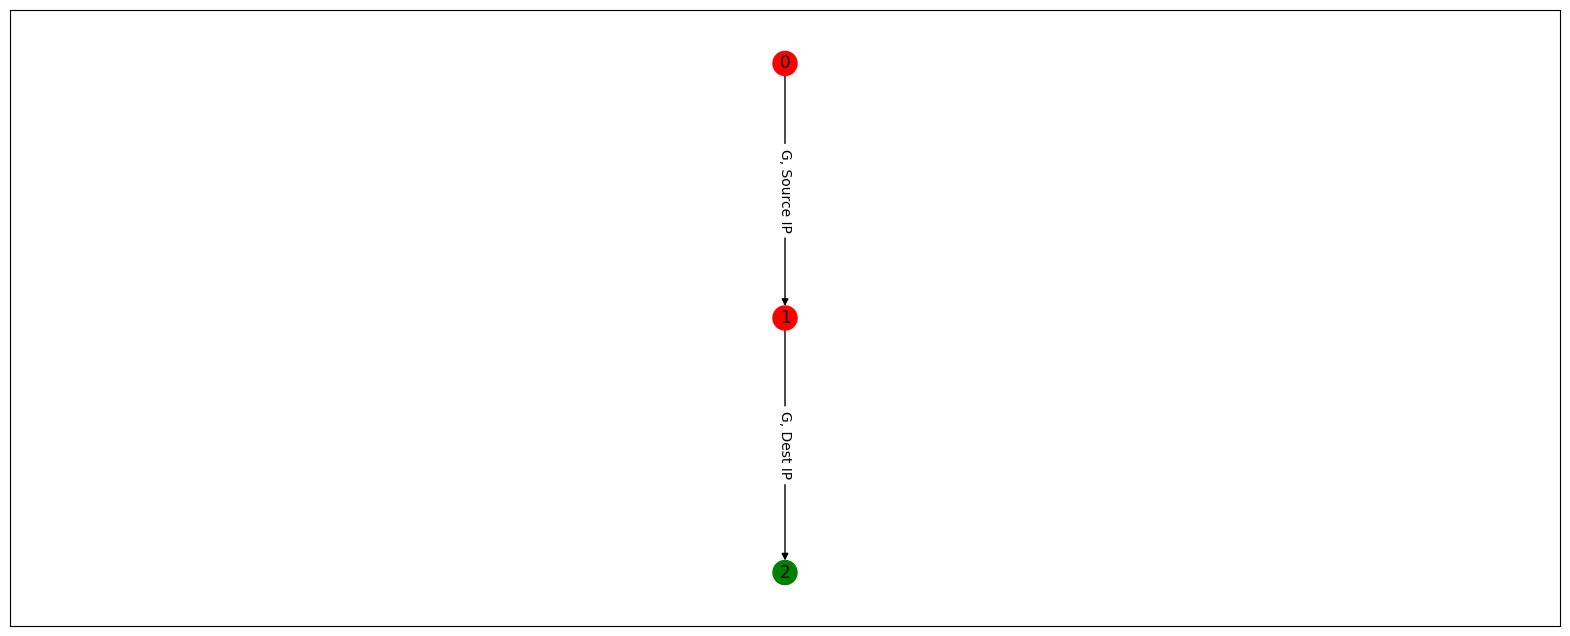

packet_number
ip_src       ip_dst                       
10.42.42.25  10.255.255.255              4
             10.42.42.253             2007
             10.42.42.50                60
10.42.42.253 10.42.42.25              3405
             10.42.42.50              2044
             10.42.42.56              2013
10.42.42.50  10.255.255.255             12
             10.42.42.25                40
             10.42.42.253             2027
10.42.42.56  10.42.42.253             2013

Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.500, std=0.000
Diversity coefficient applied (main calc): 2.0
KL coefficient applied: 1.5
MASTER-EXACT REWARD:
   action_type: 1
   kl_distance: 1.0667122848249353
   compaction_gain: 0
   total_interestingness: 1.0667122848249353
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.500, std=0.000
BEFORE coeff: r_snorkel_humanity=0.000000
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=0.000000
Snorkel humanity: 0.000000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.500, std=0.000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


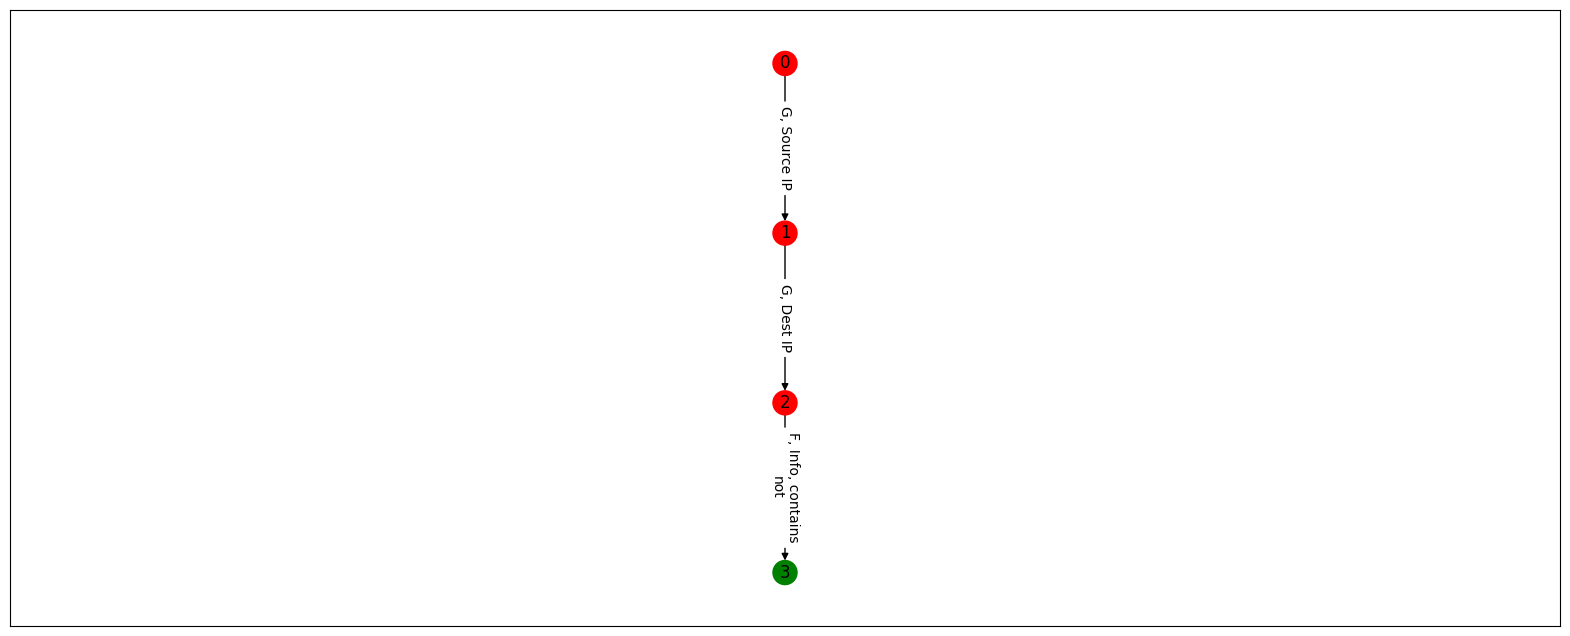

packet_number
ip_src      ip_dst                     
10.42.42.50 10.42.42.25               8
            10.42.42.253              1

Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.014, std=0.000
BACK ACTION: humanity rewards only
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.014, std=0.000
BEFORE coeff: r_snorkel_humanity=-0.971397
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=-0.971397
Snorkel humanity: -0.971397


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.500, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


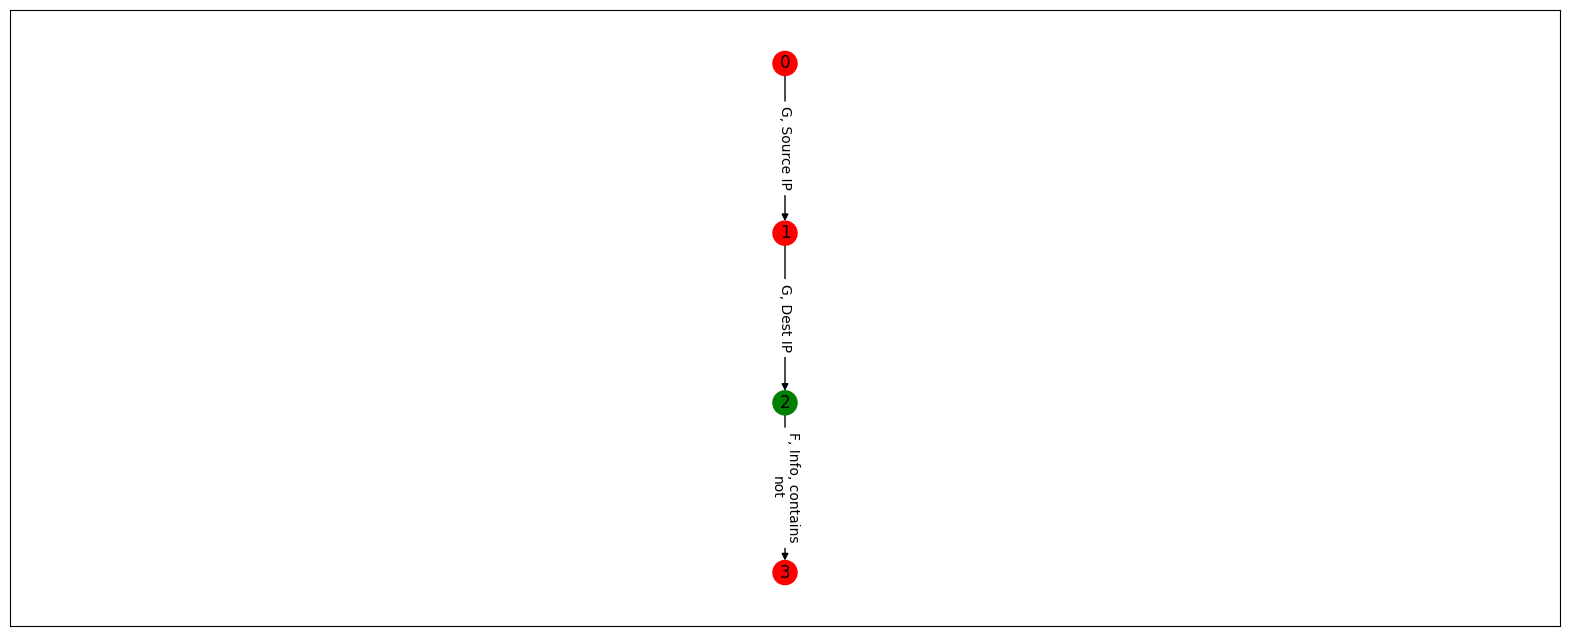

Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.036, std=0.000
BACK ACTION: humanity rewards only
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.036, std=0.000
BEFORE coeff: r_snorkel_humanity=-0.928049
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=-0.928049
Snorkel humanity: -0.928049


Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.500, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


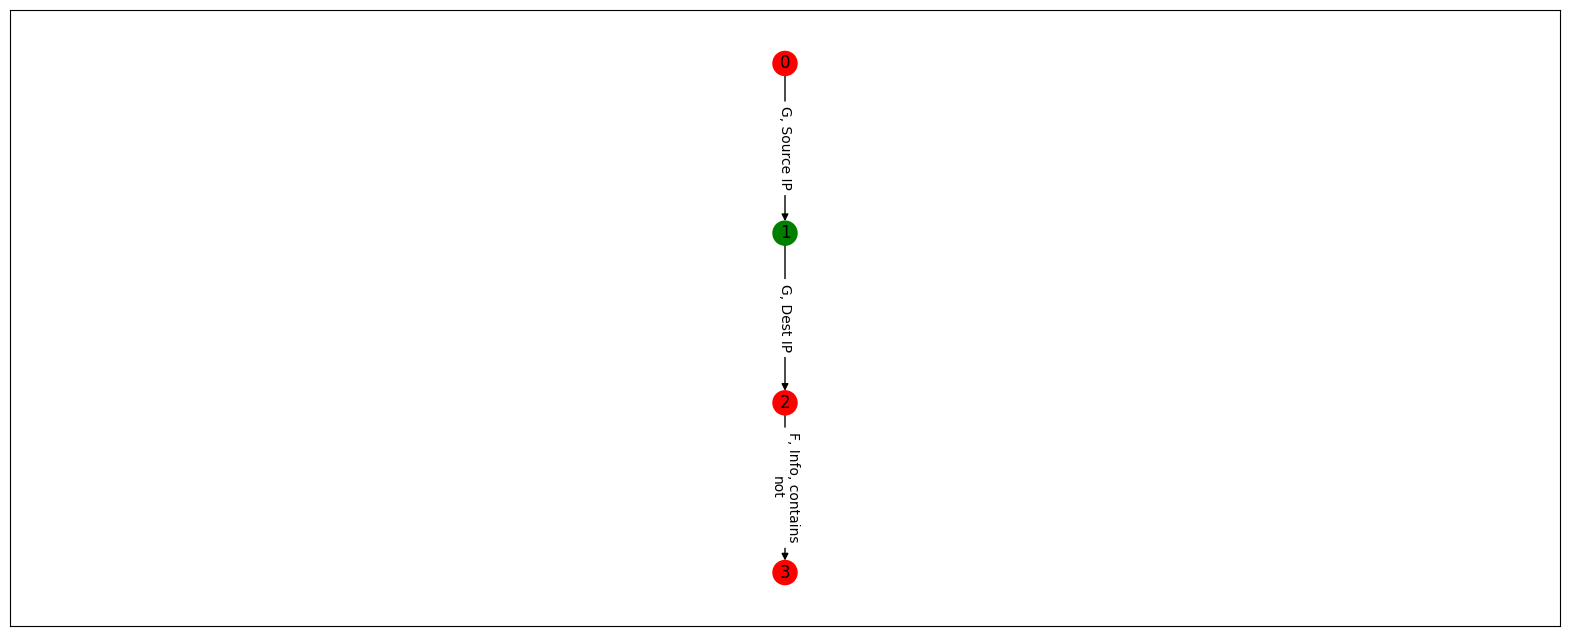

Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.191, std=0.000
Diversity coefficient applied (main calc): 2.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


KL coefficient applied: 1.5
MASTER-EXACT REWARD:
   action_type: 1
   kl_distance: 1.01532803347324
   compaction_gain: 0
   total_interestingness: 1.01532803347324
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.191, std=0.000
BEFORE coeff: r_snorkel_humanity=-0.617648
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=-0.617648
Snorkel humanity: -0.617648


Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.500, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.001, std=0.000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


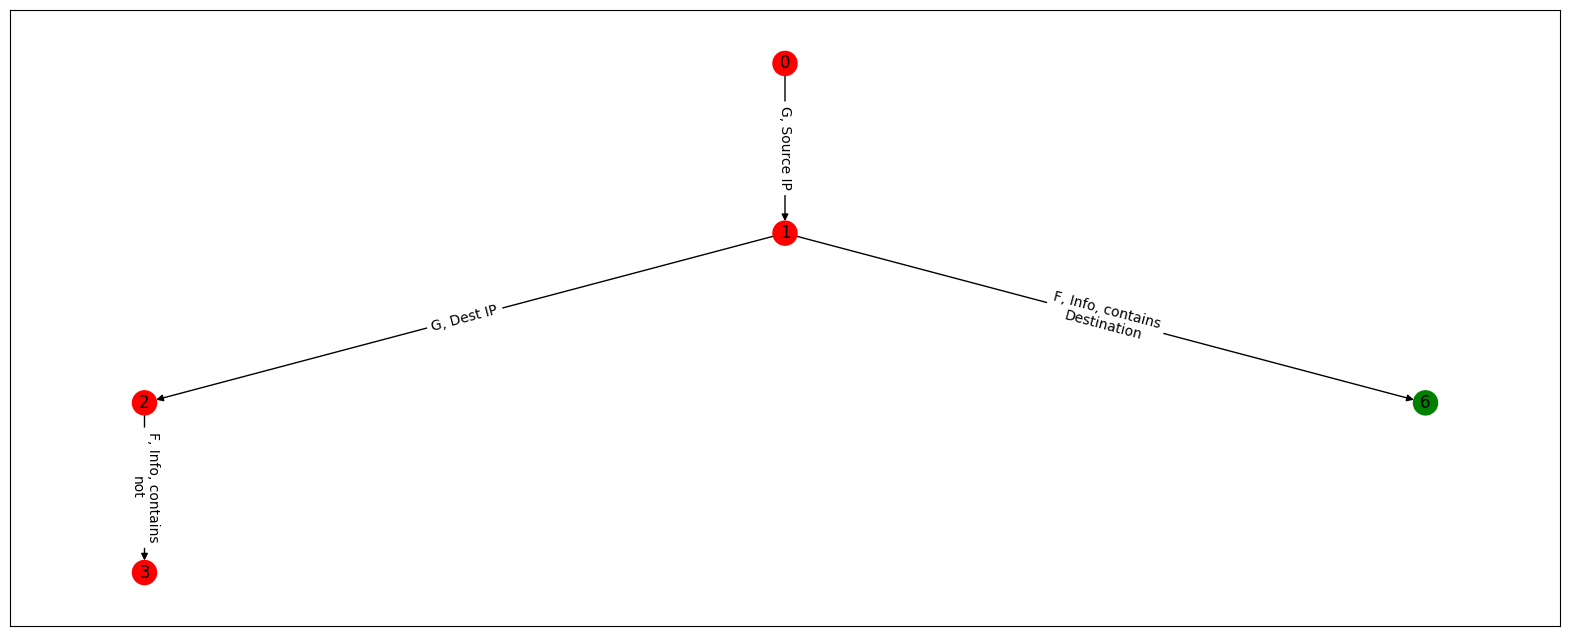

,packet_number
ip_src,
10.42.42.25,1
10.42.42.253,4
10.42.42.50,1
10.42.42.56,2


Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.014, std=0.000
BACK ACTION: humanity rewards only
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.014, std=0.000
BEFORE coeff: r_snorkel_humanity=-0.971397
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=-0.971397
Snorkel humanity: -0.971397


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.500, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.001, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


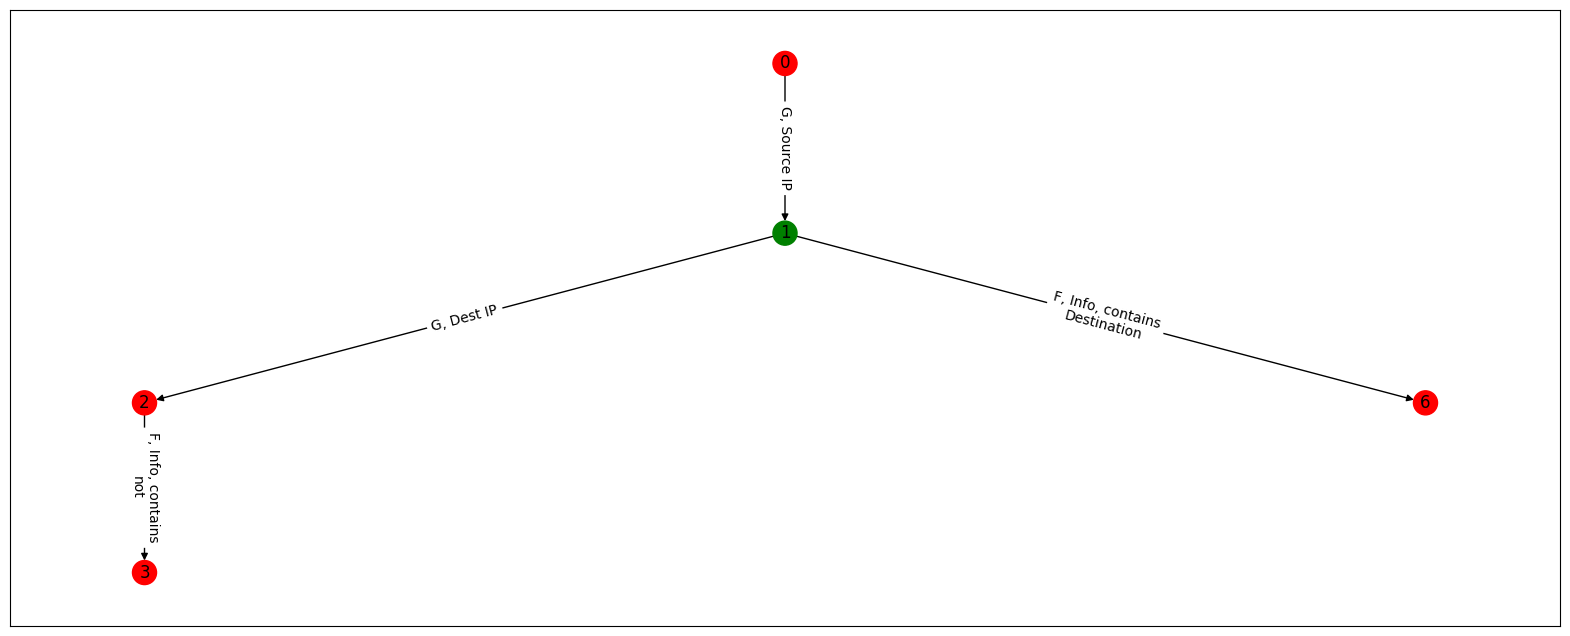

Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.036, std=0.000
BACK ACTION: humanity rewards only
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.036, std=0.000
BEFORE coeff: r_snorkel_humanity=-0.928049
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=-0.928049
Snorkel humanity: -0.928049


Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.500, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.001, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


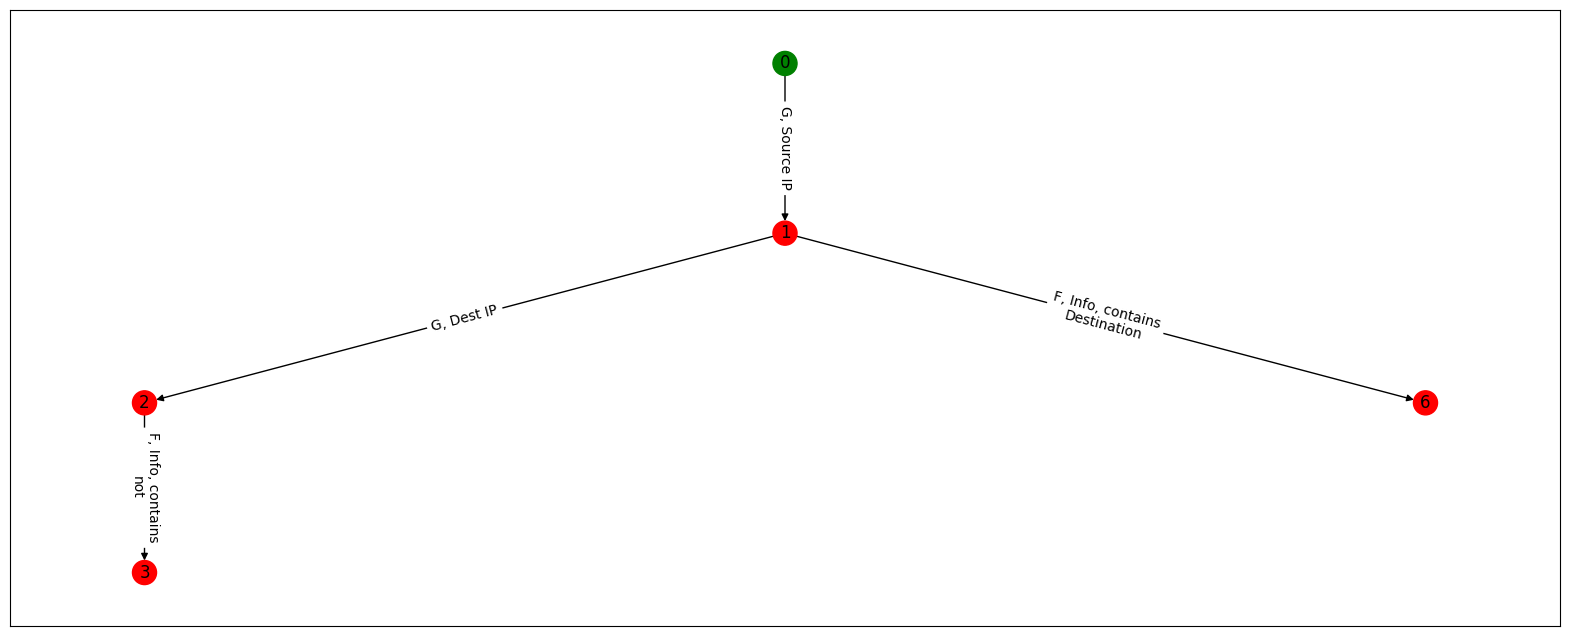

Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.011, std=0.000
Diversity coefficient applied (main calc): 2.0
Compaction coefficient applied: 2.0
MASTER-EXACT REWARD:
   action_type: 2
   kl_distance: 0
   compaction_gain: 1.972187682161801
   total_interestingness: 1.972187682161801
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.011, std=0.000
BEFORE coeff: r_snorkel_humanity=-0.978024
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=-0.978024
Snorkel humanity: -0.978024


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.500, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.001, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


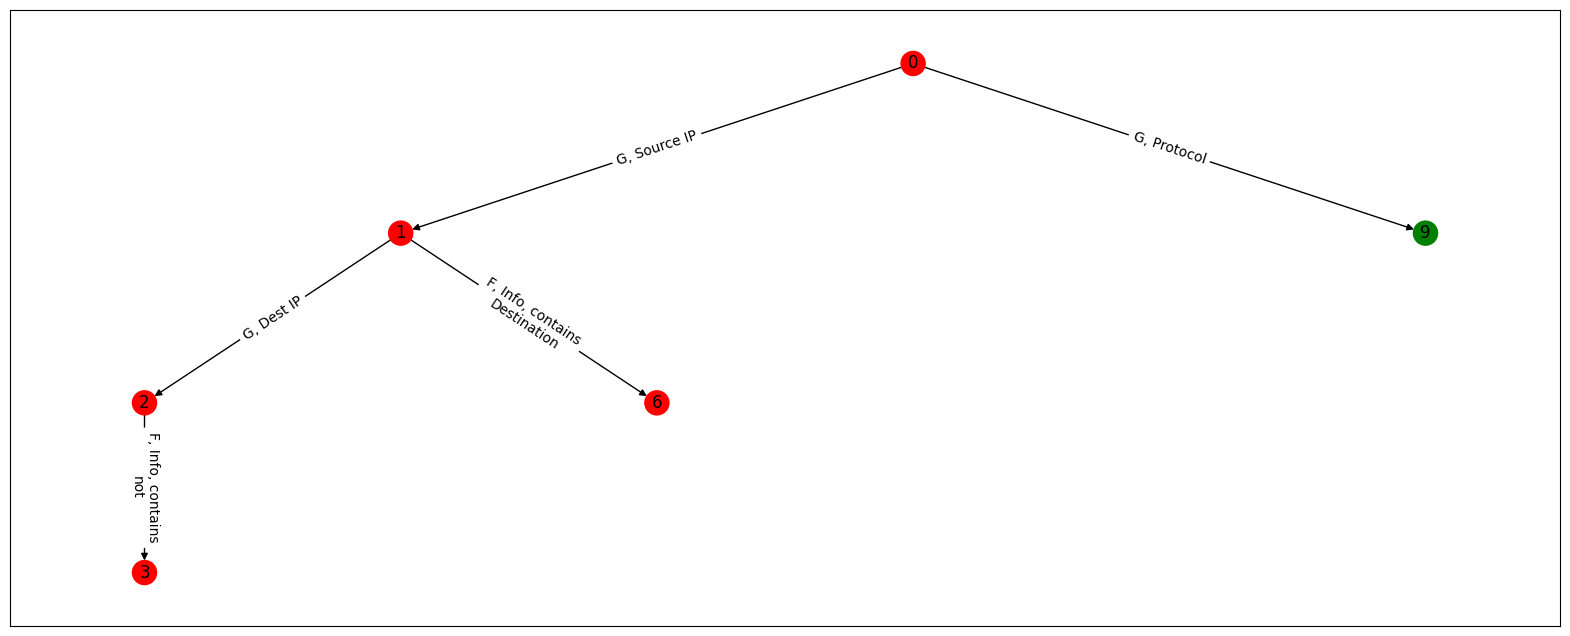

,packet_number
highest_layer,
DATA,6
DCERPC,1
ICMP,20
NBNS,20
NBSS,26
TCP,13552


Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.033, std=0.000
Diversity coefficient applied (main calc): 2.0
Compaction coefficient applied: 2.0
MASTER-EXACT REWARD:
   action_type: 2
   kl_distance: 0
   compaction_gain: 1.5333909887273478
   total_interestingness: 1.5333909887273478
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.033, std=0.000
BEFORE coeff: r_snorkel_humanity=-0.934089
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=-0.934089
Snorkel humanity: -0.934089


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.500, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.001, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


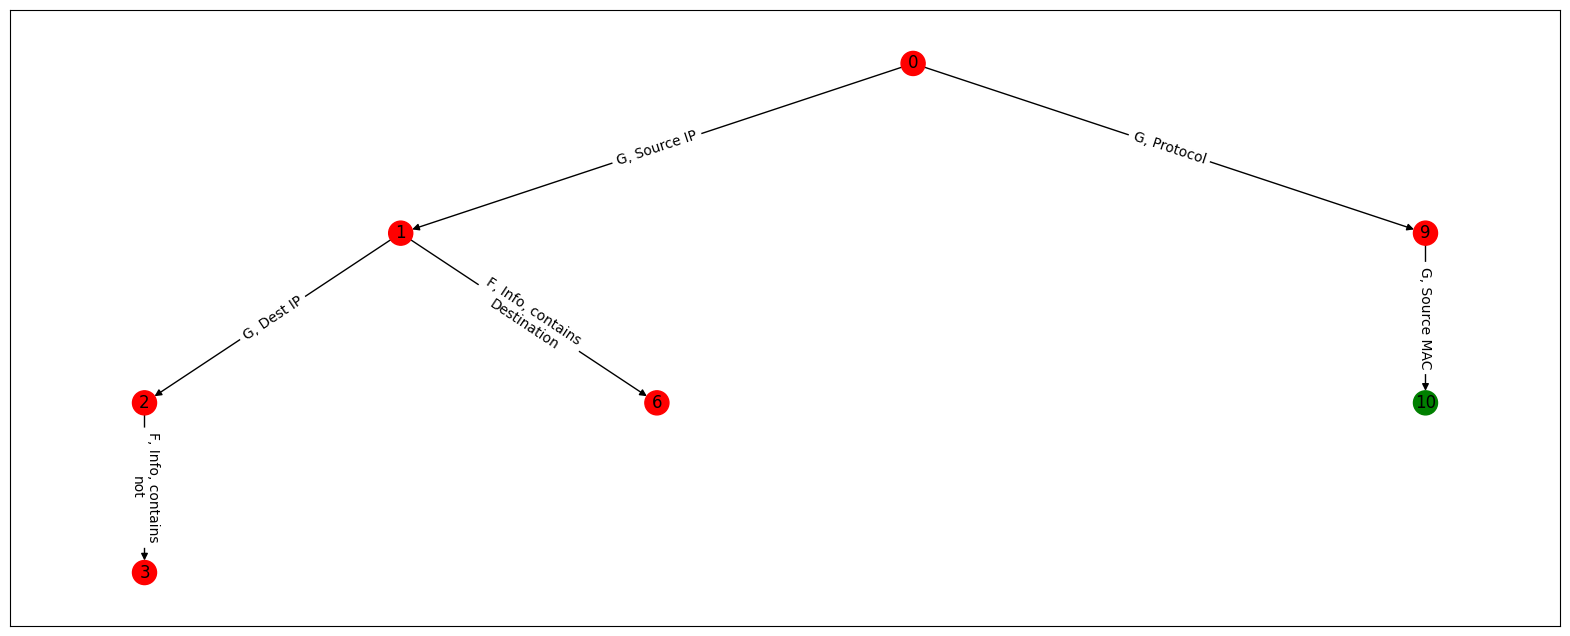

packet_number
highest_layer eth_src                         
DATA          00:23:8b:82:1f:4a              6
DCERPC        70:5a:b6:51:d7:b2              1
ICMP          00:16:cb:92:6e:dc              3
              00:23:8b:82:1f:4a              8
              00:26:22:cb:1e:79              6
              70:5a:b6:51:d7:b2              3
NBNS          00:16:cb:92:6e:dc              4
              70:5a:b6:51:d7:b2             16
NBSS          00:16:cb:92:6e:dc             12
              00:23:8b:82:1f:4a              1
              70:5a:b6:51:d7:b2             13
TCP           00:16:cb:92:6e:dc           2052
              00:23:8b:82:1f:4a           7447
              00:26:22:cb:1e:79           2007
              70:5a:b6:51:d7:b2           2046

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.006, std=0.000
Diversity coefficient applied (main calc): 2.0
Compaction coefficient applied: 2.0
MASTER-EXACT REWARD:
   action_type: 2
   kl_distance: 0
   compaction_gain: 0.014386025289930379
   total_interestingness: 0.014386025289930379
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.006, std=0.000
BEFORE coeff: r_snorkel_humanity=-0.988323
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=-0.988323
Snorkel humanity: -0.988323


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.500, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.001, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


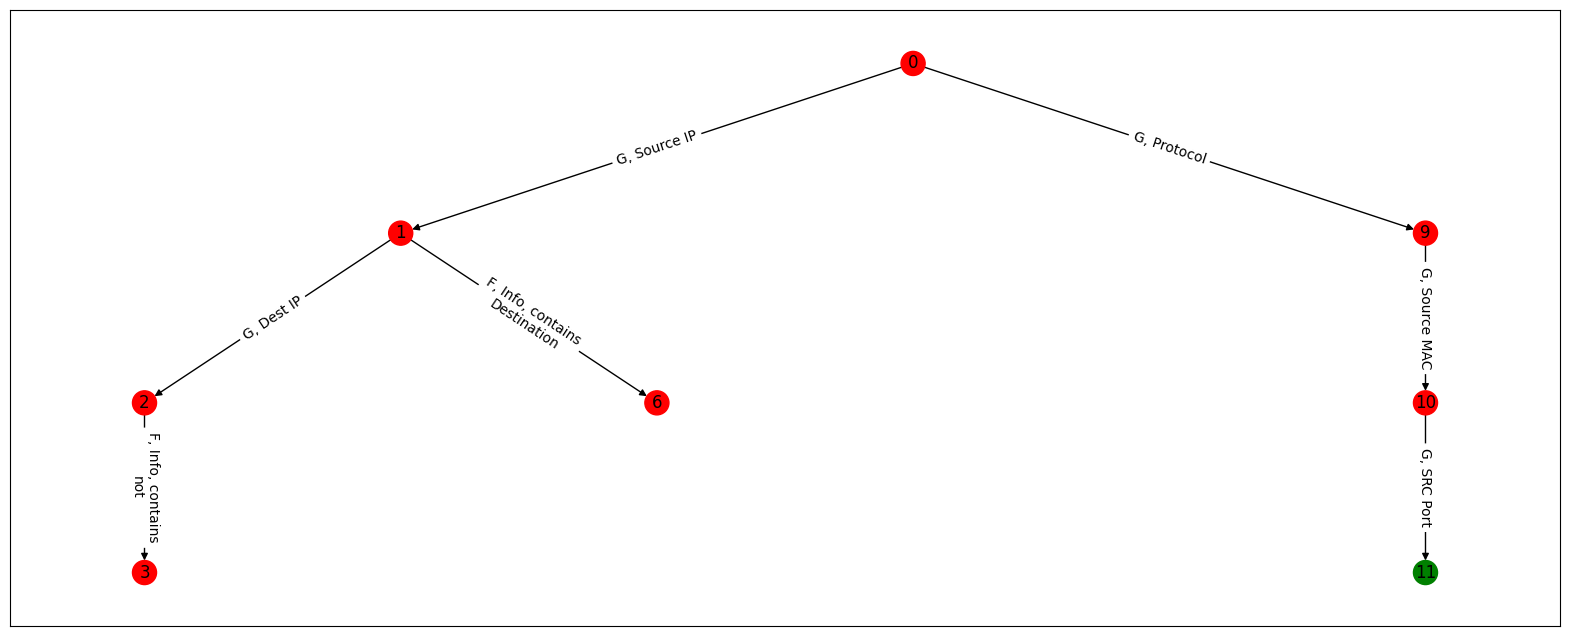

packet_number
highest_layer eth_src           tcp_srcport               
DATA          00:23:8b:82:1f:4a -1                       4
                                 43490                   1
                                 43492                   1
DCERPC        70:5a:b6:51:d7:b2  135                     1
ICMP          00:16:cb:92:6e:dc -1                       3
...                                                    ...
TCP           70:5a:b6:51:d7:b2  64623                   2
                                 64680                   2
                                 65000                   2
                                 65129                   2
                                 65389                   2

[6488 rows x 1 columns]

Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.500, std=0.000
Diversity coefficient applied (main calc): 2.0
KL coefficient applied: 1.5
MASTER-EXACT REWARD:
   action_type: 1
   kl_distance: 1.0372924418763247
   compaction_gain: 0
   total_interestingness: 1.0372924418763247
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.500, std=0.000
BEFORE coeff: r_snorkel_humanity=0.000000
Using current humanity_coeff: 1.0
AFTER coeff: r_snorkel_humanity=0.000000
Snorkel humanity: 0.000000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.500, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Rule-based humanity coefficient applied: 1.0
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.001, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000, std=0.000
Using REAL LabelModel.predict_proba() on (1, 51) matrix
Real Snorkel predictions: mean=0.000

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


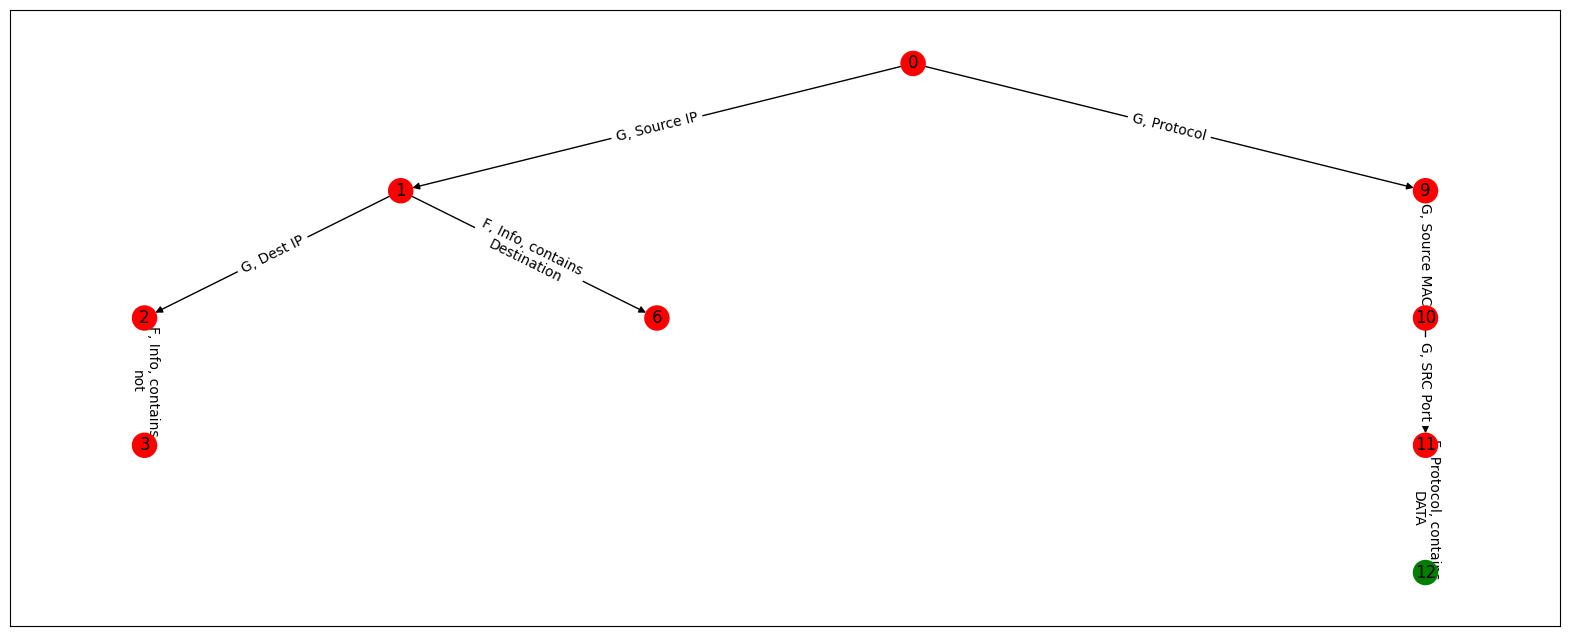

packet_number
highest_layer eth_src           tcp_srcport               
DATA          00:23:8b:82:1f:4a -1                       4
                                 43490                   1
                                 43492                   1

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
# Set dataset_number
dataset_number = 3

# Set actions
action_vecs = [
[2, 6, 0, 0.0, 0, 0],                     #  1: Group action
[2, 5, 0, 0.0, 0, 0],                     #  2: Group action
[1, 4, 8, -0.49928829073905945, 0, 0],    #  3: Filter action
[0, 0, 0, 0.0, 0, 0],                     #  4: Back
[0, 0, 0, 0.0, 0, 0],                     #  5: Back
[1, 4, 8, -0.4994085431098938, 0, 0],     #  6: Filter action
[0, 0, 0, 0.0, 0, 0],                     #  7: Back
[0, 0, 0, 0.0, 0, 0],                     #  8: Back
[2, 3, 0, 0.0, 0, 0],                     #  9: Group action
[2, 2, 0, 0.0, 0, 0],                     # 10: Group action
[2, 10, 0, 0.0, 0, 0],                    # 11: Group action
[1, 3, 8, -0.4997364282608032, 0, 0],     # 12: Filter action
]

info_hist, r_sum = run_episode_analyst_view(
    dataset_number=dataset_number,
    env=env,
    compressed=False,
    filter_by_field=True,
    continuous_filter_term=True,
    actions_lst=action_vecs,
)


## Action Vector Format

Each action is a 6-element vector: `[action_type, param1, param2, param3, param4, param5]`

### Action Types:
- `0` = Back action
- `1` = Filter action
- `2` = Group action

### For Filter Actions:
- `param1` = column index
- `param2` = condition (eq, neq, gt, lt, etc.)
- `param3` = term (continuous value mapped to actual filter term)

### For Group Actions:
- `param1` = group column index
- `param2` = aggregation column index
- `param3` = aggregation function (len, sum, mean, etc.)

### For Back Actions:
- All params are typically 0 or don't matter


## Next Steps

Now that you understand the basics, you can:

1. **Explore other notebooks:**
   - `ATENA-TF-Welcome.ipynb` - Modern introduction with trained agents
   - `Live_Recommendations_System.ipynb` - Interactive recommender
   - `Master_Compatible_Evaluation.ipynb` - Comprehensive evaluation
   - `evaluate_agent_notebook.ipynb` - Agent performance analysis

2. **Train your own agent:**
   ```bash
   python main.py
   ```

3. **Modify configurations:**
   - Edit `Configuration/config.py` to change:
     - Reward coefficients
     - Dataset schema
     - Episode length
     - Training hyperparameters

4. **Create custom action sequences:**
   - Use the action vector format above
   - Test different exploration strategies
   - Compare rewards across different approaches

5. **Analyze reward components:**
   - Study which actions get high rewards
   - Understand the humanity scoring
   - Optimize for different reward components


## Key Differences from Original ATENA-Master

While this notebook replicates the original structure, there are some key differences in the TF2 version:

1. **Backend**: Uses TensorFlow 2 instead of ChainerRL
2. **Algorithm**: PPO implementation instead of ChainerRL's PPO
3. **Environment**: Enhanced environment with better logging and tracking
4. **Snorkel**: Updated Snorkel compatibility layer for newer Python/libraries
5. **Reward System**: Improved reward stabilization and coefficient handling
6. **Evaluation**: More comprehensive evaluation metrics and tools

The core ATENA concepts, action space, and reward structure remain the same!
